In [2]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the dataset
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.shape

(374, 13)

## Data Preprocessing

In [5]:
# Check for missing values
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [6]:
# Replacing the null values with 'None' in the column 'Sleep Disorder'
df['Sleep Disorder'].fillna('None', inplace=True)

C:\Users\mdasi\AppData\Local\Temp\ipykernel_4124\864532181.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna('None', inplace=True)


In [7]:
df.isnull().sum()

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

In [8]:
# Drop column Person ID
df.drop('Person ID', axis=1, inplace=True)

In [9]:
# Checking the number of unique values in each column
print("Unique values in each column are:")
for col in df.columns:
    print(col, df[col].nunique())

Unique values in each column are:
Gender 2
Age 31
Occupation 11
Sleep Duration 27
Quality of Sleep 6
Physical Activity Level 16
Stress Level 6
BMI Category 4
Blood Pressure 25
Heart Rate 19
Daily Steps 20
Sleep Disorder 3


In [10]:
# To see what are the unique values
for col in df.columns:
    print(df[col].value_counts())
    print("-------------------------")

Gender
Male      189
Female    185
Name: count, dtype: int64
-------------------------
Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
33    13
29    13
30    13
36    12
35    12
41    12
49    11
42     9
57     9
52     9
51     8
54     7
58     6
28     5
40     4
48     3
55     2
34     2
56     2
27     1
Name: count, dtype: int64
-------------------------
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
-------------------------
Sleep Duration
7.2    36
6.0    31
7.8    28
6.5    26
6.1    25
7.7    24
6.6    20
7.1    19
8.1    15
7.3    14
8.4    14
8.0    13
6.3    13
8.5    13
6.2    12
8.2    11
7.6    10
6.4     9
7.9     7
8.3     5
7.4

# Splitting the blood pressure into systolic and diastolic

In [11]:
# Splitting the blood pressure into two columns
df['systolic_bp'] = df['Blood Pressure'].apply(lambda x : x.split('/')[0])
df['diastolic_bp'] = df['Blood Pressure'].apply(lambda x : x.split('/')[1])

# Dropping the blood pressure column
df.drop('Blood Pressure', axis=1, inplace=True)

In [12]:
# Replacing the normal weight with normal in BMI column
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

In [13]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,systolic_bp,diastolic_bp
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


# Checking the unique values from each categorical column

In [14]:
# Unique values from categorical columns
print(df.Occupation.unique())
print('\n')
print(df['BMI Category'].unique())
print('\n')
print(df['Sleep Disorder'].unique())

['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']


['Overweight' 'Normal' 'Obese']


['None' 'Sleep Apnea' 'Insomnia']


# EDA

<Axes: xlabel='Sleep Disorder', ylabel='count'>

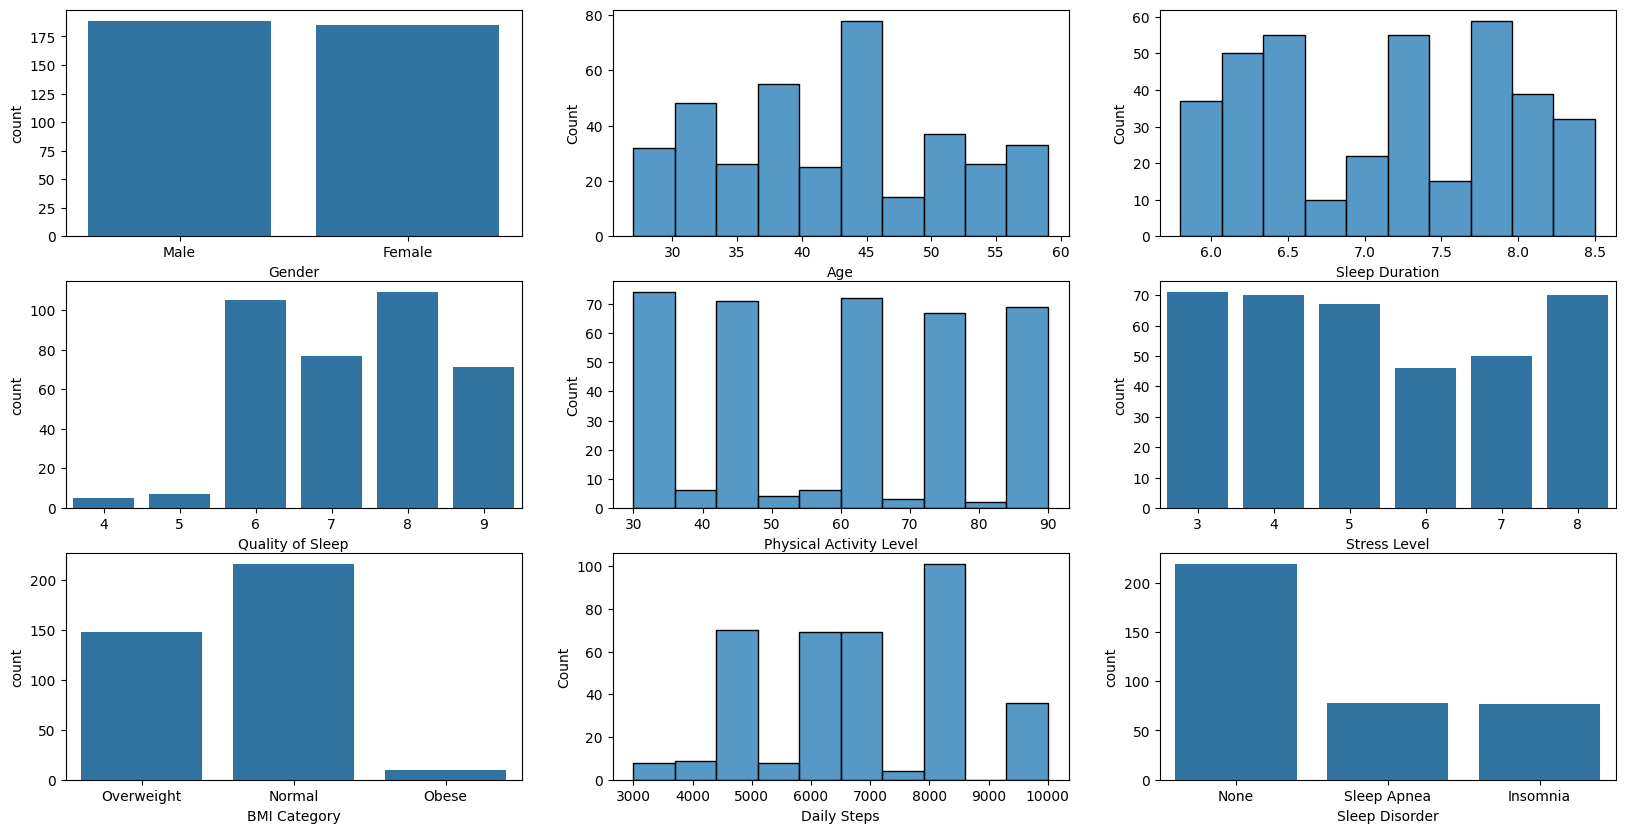

In [15]:
fig, ax = plt.subplots(3,3,figsize=(20,10))
sns.countplot(x = 'Gender', data = df, ax = ax[0,0])
sns.histplot(x = 'Age', data = df, ax = ax[0,1], bins = 10)
sns.histplot(x = 'Sleep Duration', data = df, ax = ax[0,2], bins = 10)
sns.countplot(x = 'Quality of Sleep', data = df, ax = ax[1,0])
sns.histplot(x = 'Physical Activity Level', data = df, ax = ax[1,1], bins=10)
sns.countplot(x = 'Stress Level', data = df, ax = ax[1,2])
sns.countplot(x = 'BMI Category', data = df, ax = ax[2, 0])
sns.histplot(x = 'Daily Steps', data = df, ax = ax[2,1], bins = 10)
sns.countplot(x = 'Sleep Disorder', data = df, ax = ax[2,2])

# Gender and Sleep Disorder

Text(0.5, 1.0, 'Gender and Sleep Disorder')

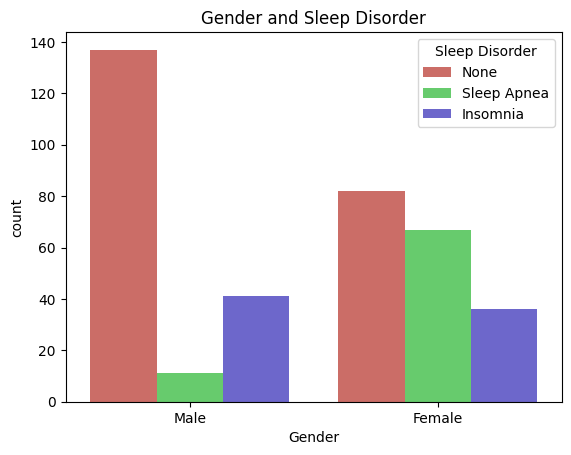

In [17]:
# gender count plot
sns.countplot(x = 'Gender', data = df, palette = 'hls', hue = 'Sleep Disorder').set_title('Gender and Sleep Disorder')

# Effect of Occupation on Sleep Disorder

C:\Users\mdasi\AppData\Local\Temp\ipykernel_4124\360875477.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)


[Text(0, 0, 'Software Engineer'),
 Text(1, 0, 'Doctor'),
 Text(2, 0, 'Sales Representative'),
 Text(3, 0, 'Teacher'),
 Text(4, 0, 'Nurse'),
 Text(5, 0, 'Engineer'),
 Text(6, 0, 'Accountant'),
 Text(7, 0, 'Scientist'),
 Text(8, 0, 'Lawyer'),
 Text(9, 0, 'Salesperson'),
 Text(10, 0, 'Manager')]

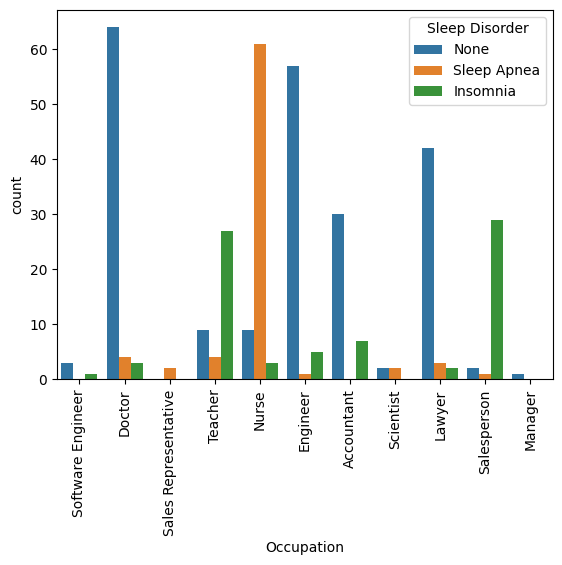

In [18]:
ax = sns.countplot(x = 'Occupation', data = df, hue = 'Sleep Disorder')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)

# BMI and Sleep Disorder

Text(0.5, 1.0, 'BMI Category and Sleep Disorder')

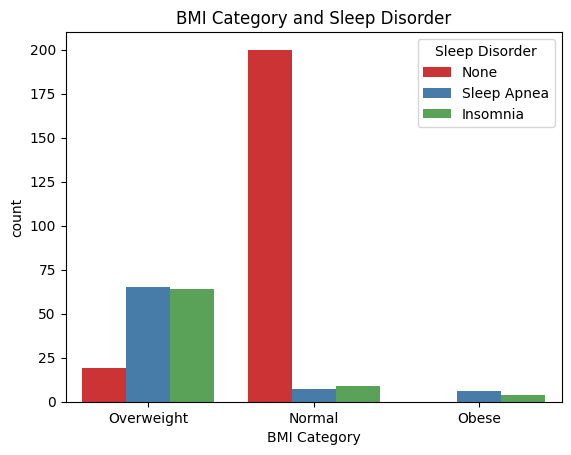

In [20]:
sns.countplot(x = 'BMI Category', hue = 'Sleep Disorder', data = df, palette = 'Set1').set_title('BMI Category and Sleep Disorder')

# Data Preprocessing Part 2

In [21]:
# Label Encoding for categorical variables
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

In [23]:
vars = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
for i in vars:
    label_encoder.fit(df[i].unique())
    df[i] = label_encoder.transform(df[i])
    print(i, ':', df[i].unique())

Gender : [1 0]
Occupation : [ 9  1  6 10  5  2  0  8  3  7  4]
BMI Category : [2 0 1]
Sleep Disorder : [1 2 0]


In [24]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,systolic_bp,diastolic_bp
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90


# Correlation Matrix Heatmap

<Axes: >

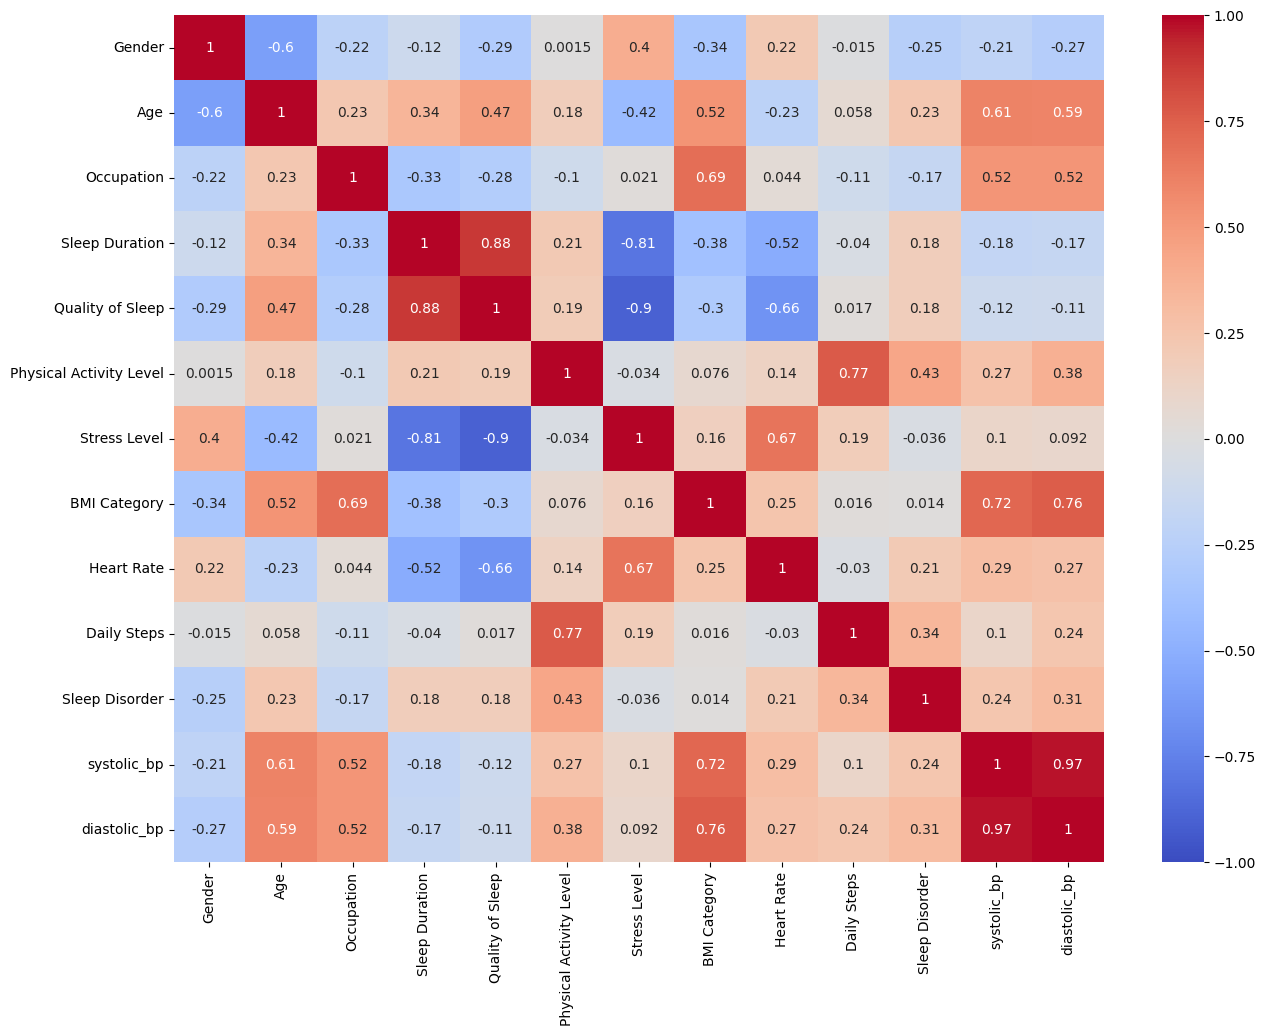

In [27]:
# Correlation Matrix Heatmap
plt.figure(figsize=(15, 11))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmax=1.0, vmin=-1.0)

# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
print(df.shape)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(374, 13)
(261, 12)
(261,)
(113, 12)
(113,)


In [29]:
X_train.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,systolic_bp,diastolic_bp
19,1,30,1,7.6,7,75,6,0,70,8000,120,80
357,0,58,5,8.0,9,75,3,2,68,7000,140,95
79,1,33,1,6.0,6,30,8,0,72,5000,125,80
167,1,41,3,7.1,7,55,6,2,72,6000,125,82
18,0,29,5,6.5,5,40,7,0,80,4000,132,87


# Data Normalization

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train_scale = scaler.transform(X_train)
X_test_scale = scaler.transform(X_test)

# Model Building
For model building, I will use the following two algorithms:
1. Decision Tree Classifier
2. Random Forest Classifier

Decision Tree Classifier

In [35]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree

DecisionTreeClassifier()

In [36]:
# Train the model with train dataset
dtree.fit(X_train_scale, y_train)

DecisionTreeClassifier()

In [37]:
# Training accuracy
print("Training Accuracy: ", dtree.score(X_train_scale, y_train))

Training Accuracy:  0.9348659003831418


# Decision Tree Model Evaluation

In [38]:
d_pred = dtree.predict(X_test_scale)
d_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 0, 2, 0, 0,
       1, 1, 1, 1, 0, 1, 2, 2, 2, 1, 0, 2, 0, 2, 2, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 2, 2, 0, 1, 1, 2, 0, 1, 2, 1, 1, 1, 2, 0, 2,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 2, 0, 1, 1, 0, 2, 1, 1,
       2, 1, 0])

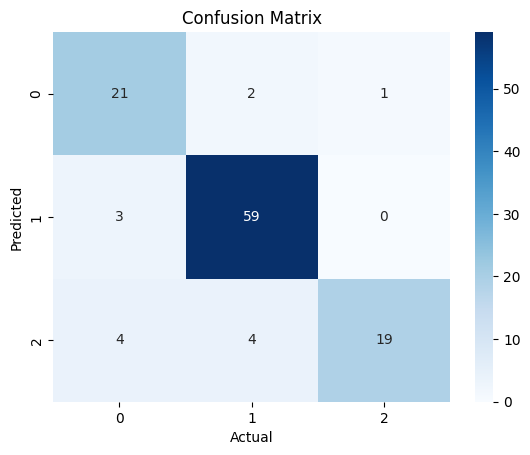

In [39]:
# Using confusion matrix heatmap to visualize the model accuracy
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, d_pred), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(classification_report(y_test, d_pred))
print(accuracy_score(y_test, d_pred))

              precision    recall  f1-score   support

           0       0.75      0.88      0.81        24
           1       0.91      0.95      0.93        62
           2       0.95      0.70      0.81        27

    accuracy                           0.88       113
   macro avg       0.87      0.84      0.85       113
weighted avg       0.88      0.88      0.87       113

0.8761061946902655


# Distribution plot for predicted and actual values

C:\Users\mdasi\AppData\Local\Temp\ipykernel_4124\1330992443.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
C:\Users\mdasi\AppData\Local\Temp\ipykernel_4124\1330992443.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distp

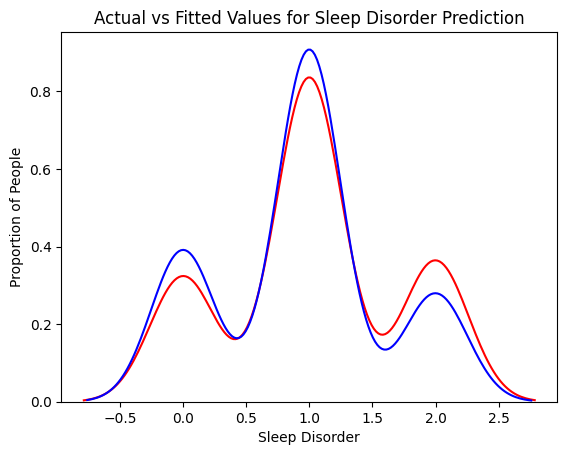

In [45]:
ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(d_pred, hist=False, color="b", label="Fitted Values", ax=ax)
plt.title('Actual vs Fitted Values for Sleep Disorder Prediction')
plt.xlabel('Sleep Disorder')
plt.ylabel('Proportion of People')
plt.show()

# Random Forest Classifier Evaluation

In [46]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

In [47]:
# Train the model with train dataset
rfc.fit(X_train_scale, y_train)

RandomForestClassifier(random_state=42)

In [48]:
# Training Accuracy
print("Training accuracy: ", rfc.score(X_train_scale, y_train))

Training accuracy:  0.9348659003831418


# Random Forest Classifier Evaluation

In [49]:
rfc_pred = rfc.predict(X_test_scale)
rfc_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 0, 2, 0, 0,
       1, 1, 1, 1, 2, 1, 2, 0, 2, 1, 0, 2, 0, 2, 2, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 2, 2, 0, 1, 1, 2, 0, 1, 2, 1, 1, 1, 2, 1, 2,
       1, 1, 2, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2, 0, 2, 1, 1,
       2, 1, 0])

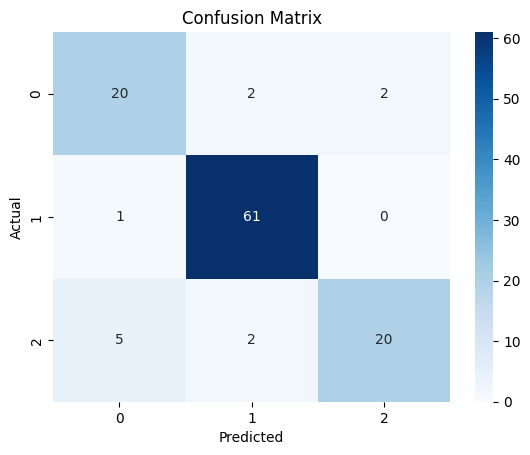

In [50]:
# Confusion matrix heatmap
sns.heatmap(confusion_matrix(y_test, rfc_pred), annot=True, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Distribution plot for predicted and actual values

C:\Users\mdasi\AppData\Local\Temp\ipykernel_4124\337812563.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
C:\Users\mdasi\AppData\Local\Temp\ipykernel_4124\337812563.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplo

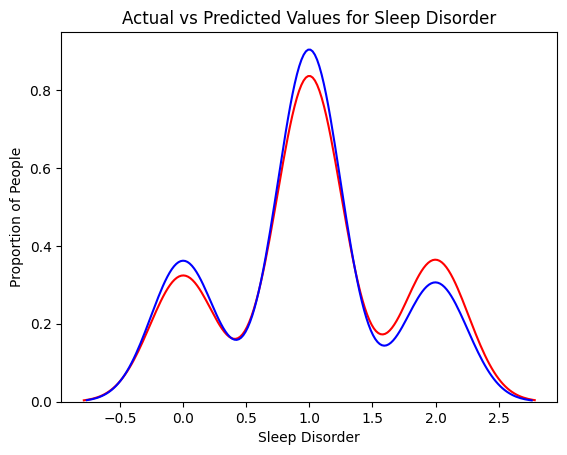

In [51]:
ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(rfc_pred, hist=False, color="b", label="Predicted Values", ax=ax)
plt.title('Actual vs Predicted Values for Sleep Disorder')
plt.xlabel('Sleep Disorder')
plt.ylabel('Proportion of People')
plt.show()

# Classification report

In [52]:
print(classification_report(y_test, rfc_pred))
print("Accuracy: ", accuracy_score(y_test, rfc_pred))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        24
           1       0.94      0.98      0.96        62
           2       0.91      0.74      0.82        27

    accuracy                           0.89       113
   macro avg       0.87      0.85      0.86       113
weighted avg       0.90      0.89      0.89       113

Accuracy:  0.8938053097345132


# Deployment code

In [53]:
# Save Model Objects
import joblib

In [54]:
joblib.dump(rfc, "RFC_MODEL.pkl")
joblib.dump(scaler, "SCALER_MODEL.pkl")

['SCALER_MODEL.pkl']

In [55]:
model = joblib.load("RFC_MODEL.pkl")
scaler_model = joblib.load("SCALER_MODEL.pkl")

# Create Sample Input

In [58]:
X_train.iloc[0].to_dict()

{'Gender': 1,
 'Age': 30,
 'Occupation': 1,
 'Sleep Duration': 7.6,
 'Quality of Sleep': 7,
 'Physical Activity Level': 75,
 'Stress Level': 6,
 'BMI Category': 0,
 'Heart Rate': 70,
 'Daily Steps': 8000,
 'systolic_bp': '120',
 'diastolic_bp': '80'}

In [59]:
sample = X_train.iloc[0]
sample = sample.to_dict()

In [61]:
# Prediction for Single Data Point
sample = {'Gender': 1,
 'Age': 30,
 'Occupation': 1,
 'Sleep Duration': 7.6,
 'Quality of Sleep': 7,
 'Physical Activity Level': 75,
 'Stress Level': 6,
 'BMI Category': 0,
 'Heart Rate': 70,
 'Daily Steps': 8000,
 'systolic_bp': '120',
 'diastolic_bp': '80'}

In [62]:
def ask_user():
    user_data = dict()

    ans = float(input("Enter your Gender : Female -> 0 || Male -> 1"))
    user_data["Gender"] = ans

    ans = float(input("Enter your Age : "))
    user_data["Age"] = ans

    ans = float(input("Enter your Occupation (Enter a number from ) for Nurse to 10 for Manager : "))
    user_data["Occupation"] = ans

    ans = float(input("Enter your Sleep Duration (in hours) : "))
    user_data["Sleep Duration"] = ans

    ans = float(input("Enter your Quality of Sleep (scale 1-10) : "))
    user_data["Quality of Sleep"] = ans

    ans = float(input("Enter your Physical Activity Level (minutes of activity) : "))
    user_data["Physical Activity Level"] = ans

    ans = float(input("Enter your Stress Level (scale 1-10) : "))
    user_data["Stress Level"] = ans

    ans = float(input("Enter your BMI Category (0: Normal, 1: Overweight, 2: Normal Weight, 3: Obese) : "))
    user_data["BMI Category"] = ans

    ans = float(input("Enter your Heart Rate (beats per minute) : "))
    user_data["Heart Rate"] = ans

    ans = float(input("Enter your Daily Steps: "))
    user_data["Daily Steps"] = ans

    ans = float(input("Enter your Systolic Blood Pressure: "))
    user_data["systolic_bp"] = ans

    ans = float(input("Enter your Diastolic Blood Pressure: "))
    user_data["diastolic_bp"] = ans

    return user_data

In [63]:
user_data = ask_user()

In [64]:
user_data

{'Gender': 1.0,
 'Age': 22.0,
 'Occupation': 8.0,
 'Sleep Duration': 6.0,
 'Quality of Sleep': 8.0,
 'Physical Activity Level': 45.0,
 'Stress Level': 8.0,
 'BMI Category': 3.0,
 'Heart Rate': 45.0,
 'Daily Steps': 400.0,
 'systolic_bp': 18.0,
 'diastolic_bp': 65.0}

In [66]:
list(user_data.values())

[1.0, 22.0, 8.0, 6.0, 8.0, 45.0, 8.0, 3.0, 45.0, 400.0, 18.0, 65.0]

# Creating the Inference Pipeline

In [67]:
def return_prediction(model, scaler, data):
    c = list(data.values())
    e = np.array(c, dtype=float)
    w = scaler.transform([e])
    res = model.predict(w)
    label = ["Insomnia", "None", "Sleep Apnea",]
    return label[res[0]]

In [68]:
return_prediction(model=model,
                  scaler=scaler_model,
                  data=user_data)

c:\Users\mdasi\anaconda3\envs\disorder-prediction\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'None'

# Gradio Deployment

In [69]:
import gradio as gr
import numpy as np
import pickle

c:\Users\mdasi\anaconda3\envs\disorder-prediction\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [70]:
# Load the pre-trained model and scaler
model = joblib.load("RFC_MODEL.pkl")
scaler_model = joblib.load("SCALER_MODEL.pkl")

In [73]:
def return_prediction(model, scaler, data):
    """
    Convert input data to a NumPy array, scale it, and use the model to predict.
    Returns a sleep disorder label based on the predicted index.
    """

    c = list(data.values())
    e = np.array(c, dtype=float)
    w = scaler.transform([e])
    res = model.predict(w)
    label = ["Insomnia", "None", "Sleep Apnea"]
    return label[res[0]]

def predict_ui(gender, age, occupation, sleep_duration, quality_of_sleep,
               physical_activity_level, stress_level, bmi_category,
               heart_rate, daily_steps, systolic_bp, diastolic_bp):
    
    """Map UI inputs to numeric codes and run the prediction pipeline.
    
    Categorical mappings (using ascending order):
        - Gender: Female -> 0, Male -> 1
        - Occupation: Alphabetically sorted list.
        - BMI Category: Alphabetically sorted list.
    """

    # Map Gender: "Female" become 0, "Male" becomes 1
    gender_code = 0 if gender == "Female" else 1

    # Define occupations in alphabetical order (as produced by a label encoder)

    occupation_options = [
        "Accountant", "Doctor", "Engineer", "Lawyer", "Manager",
        "Nurse", "Sales Respresentative", "Salesperson", "Scientist",
        "Software Engineer", "Teacher"
    ]

    occupation_code = occupation_options.index(occupation)

    # Define BMI categories in alphabetical order
    bmi_options = ["Normal", "Normal Weight", "Obese", "Overweight"]
    bmi_code = bmi_options.index(bmi_category)

    # Build the data dictionary with all numeric values
    data = {
        "Gender": gender_code,
        "Age": age,
        "Occupation": occupation_code,
        "Sleep Duration": sleep_duration,
        "Quality of Sleep": quality_of_sleep,
        "Physical Activity Level": physical_activity_level,
        "Stress Level": stress_level,
        "BMI Category": bmi_code,
        "Heart Rate": heart_rate,
        "Daily Steps": daily_steps,
        "systolic_bp": systolic_bp,
        "diastolic_bp": diastolic_bp
    }

    return return_prediction(model, scaler, data)

# Gradio interface components

# For categorical inputs, we use Radio buttons.

gender_input = gr.Radio(choices=["Female", "Male"], label="Gender (Female -> 0, Male -> 1)", value="Female")
occupation_input = gr.Radio(
    choices=[
        "Accountant", "Doctor", "Engineer", "Lawyer", "Manager",
        "Nurse", "Sales Representative", "Salesperson", "Scientist",
        "Software Engineer", "Teacher"
    ],
    label = "Occupation", value = "Accountant"
)
bmi_input = gr.Radio(
    choices = ["Normal", "Normal Weight", "Obese", "Overweight"],
    label = "BMI Category", value="Normal"
)

# For numerical inputs, use sliders.
age_input = gr.Slider(minimum=25,
                      maximum=70,
                      step=1,
                      label="Age",
                      value=40)

sleep_duration_input = gr.Slider(minimum=5.0, maximum=10.0, step=0.1, label="Sleep Duration (hours)", value=7.0)
quality_input = gr.Slider(minimum=1, maximum=10, step=1, label="Quality of Sleep (scale 1-10)", value=7)
physical_activity_input = gr.Slider(minimum=30, maximum=100, step=1, label="Physical Activity Level (minutes)", value=60)
stress_input = gr.Slider(minimum=1, maximum=10, step=1, label="Stress Level (scale 1-10)", value=5)
heart_rate_input = gr.Slider(minimum=50, maximum=100, step=1, label="Heart Rate (BPM)", value=70)
daily_steps_input = gr.Slider(minimum=3000, maximum=15000, step=500, label="Daily Steps", value=8000)
systolic_input = gr.Slider(minimum=100, maximum=160, step=1, label="Systolic Blood Pressure", value=120)
diastolic_input = gr.Slider(minimum=60, maximum=100, step=1, label="Diastolic Blood Pressure", value=80)

# Creating the gradio interface
demo = gr.Interface(
    fn = predict_ui,
    inputs=[
        gender_input, age_input, occupation_input, sleep_duration_input, 
        quality_input, physical_activity_input, stress_input, bmi_input,
        heart_rate_input, daily_steps_input, systolic_input, diastolic_input
    ],
    outputs = gr.Textbox(label="Predicted Sleep Disorder"),
    title="Sleep Disorder Prediction",
    description = "Select your details below. Categorical choices are converted into numeric codes based on alphabetical order"
)


if __name__ == "__main__":
    demo.launch(share=True, debug=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://08d22dbae7df281d3e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


c:\Users\mdasi\anaconda3\envs\disorder-prediction\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mdasi\anaconda3\envs\disorder-prediction\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mdasi\anaconda3\envs\disorder-prediction\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://08d22dbae7df281d3e.gradio.live
